## 0. Cài đặt

In [1]:
# torch_geometric không có sẵn trên Kaggle
!pip install -q torch_geometric

import torch, torch_geometric
print("torch", torch.__version__, "| PyG", torch_geometric.__version__,
      "| GPU", torch.cuda.device_count())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.1 MB/s eta 0:00:00a 0:00:01
torch 2.10.0+cu128 | PyG 2.8.0.post1 | GPU 2


## 1. Ghi code ra /kaggle/working

Sửa code thì sửa ngay trong cell rồi chạy lại đúng cell đó.

In [2]:
%%writefile /kaggle/working/paths.py
import glob
import os

_ON_KAGGLE = os.path.isdir("/kaggle/working")


def _detect_raw_dir() -> str:
    env = os.environ.get("AML_RAW_DIR")
    if env:
        return env
    if _ON_KAGGLE:
        hits = sorted(glob.glob("/kaggle/input/**/HI-Small_Trans.csv", recursive=True))
        if not hits:
            raise FileNotFoundError(
                "Không thấy HI-Small_Trans.csv trong /kaggle/input.\n"
                "Vào Add Data -> thêm dataset "
                "'ealtman2019/ibm-transactions-for-anti-money-laundering-aml',\n"
                "hoặc đặt biến môi trường AML_RAW_DIR trỏ tới thư mục chứa file."
            )
        return os.path.dirname(hits[0])
    return "dataset_high"


RAW_DIR = _detect_raw_dir()
OUT_DIR = os.environ.get("AML_OUT_DIR") or (
    "/kaggle/working/dataset_high" if _ON_KAGGLE else "dataset_high"
)
WORK_DIR = os.path.dirname(os.path.abspath(OUT_DIR))

# --- input gốc (read-only trên Kaggle) ---
TRANS_CSV = os.path.join(RAW_DIR, "HI-Small_Trans.csv")

# --- file trung gian (ghi được) ---
SPLIT_CSV = os.path.join(OUT_DIR, "HI-Small_Trans_split_index.csv")
TX_FEAT = os.path.join(OUT_DIR, "transaction_features.parquet")
NODE_FEAT = os.path.join(OUT_DIR, "node_edge_features.parquet")
EDGE_ATTR = os.path.join(OUT_DIR, "edge_attr_{}.parquet")
TXN_MATRIX = os.path.join(OUT_DIR, "txn_matrix_{}.parquet")
GRAPHS_PT = os.path.join(OUT_DIR, "graphs.pt")
TXN_NODES = os.path.join(OUT_DIR, "txn_nodes.npy")
# --- output kết quả ---
RESULTS_CSV = os.path.join(WORK_DIR, "results.csv")
SCORES_DIR = os.path.join(WORK_DIR, "scores")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(SCORES_DIR, exist_ok=True)


def describe() -> str:
    return (f"môi trường : {'Kaggle' if _ON_KAGGLE else 'local'}\n"
            f"RAW_DIR    : {RAW_DIR}\n"
            f"OUT_DIR    : {OUT_DIR}\n"
            f"WORK_DIR   : {WORK_DIR}")


if __name__ == "__main__":
    print(describe())
    print(f"\nTRANS_CSV tồn tại: {os.path.exists(TRANS_CSV)}")

Overwriting /kaggle/working/paths.py


In [3]:
%%writefile /kaggle/working/temporal_split_index.py
import pandas as pd

from paths import TRANS_CSV, SPLIT_CSV


def main():
    # ép kiểu phòng trường hợp pandas đọc thành int và có số 0 đầu sẽ bỏ số 0 đầu
    # sẽ làm sai dữ liệu khi tạo node
    dtype = {"From Bank": str, "To Bank": str, "Account": str, "Account.1": str}
    df_trans = pd.read_csv(TRANS_CSV, dtype=dtype)

    # sắp xếp dataframe theo timestamp
    order = df_trans["Timestamp"].sort_values(kind="mergesort").index
    df_trans = df_trans.iloc[order].reset_index(drop=True)

    # chia dữ liệu theo train/test/val
    n = len(df_trans)
    t1 = int(n * 0.6)
    t2 = int(n * 0.8)
    ts1 = df_trans["Timestamp"].iloc[t1]
    ts2 = df_trans["Timestamp"].iloc[t2]

    # gán nhãn train/test/val cho tập dữ liệu mới và xuất file
    df_trans["split"] = "test"
    df_trans.loc[df_trans["Timestamp"] < ts2, "split"] = "val"
    df_trans.loc[df_trans["Timestamp"] < ts1, "split"] = "train"
    assert df_trans[df_trans.split == "train"]["Timestamp"].max() < df_trans[df_trans.split == "val"]["Timestamp"].min(), \
        "Leakage: Timestamp chong lan giua train va val"
    assert df_trans[df_trans.split == "val"]["Timestamp"].max() < df_trans[df_trans.split == "test"]["Timestamp"].min(), \
        "Leakage: Timestamp chong lan giua val va test"

    # xuất file csv
    df_trans.to_csv(SPLIT_CSV, index=False)
    print(f"Đã lưu: {SPLIT_CSV}")
    print(df_trans["split"].value_counts())


if __name__ == "__main__":
    main()

Overwriting /kaggle/working/temporal_split_index.py


In [4]:
%%writefile /kaggle/working/feature_transaction.py
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from paths import SPLIT_CSV, TX_FEAT

SRC = SPLIT_CSV
OUT = TX_FEAT

SCALE_COLS = ["amt_paid_log"]


def load_data():
    dt = {"From Bank": str, "Account": str, "To Bank": str, "Account.1": str, "split": str}
    df = pd.read_csv(SRC, dtype=dt, engine="pyarrow")
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%Y/%m/%d %H:%M")
    df["src"] = df["From Bank"] + " | " + df["Account"]
    df["dest"] = df["To Bank"] + " | " + df["Account.1"]
    return df


def build_transaction_features(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    out["amt_paid_log"] = np.log1p(df["Amount Paid"])
    out["is_cross_bank"] = (df["From Bank"] != df["To Bank"]).astype("int8")
    out["is_cross_currency"] = (df["Receiving Currency"] != df["Payment Currency"]).astype("int8")
    # out["is_round_1000"] = (df["Amount Paid"] % 1000 == 0).astype("int8")
    # out["is_round_100"] = (df["Amount Paid"] % 100 == 0).astype("int8")
    out["is_self_loop"] = (df["src"] == df["dest"]).astype("int8")

    # --- Thời gian ---
    hour = df["Timestamp"].dt.hour.astype("int16")
    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    day_of_week = df["Timestamp"].dt.dayofweek.astype("int16")
    out["dow_sin"] = np.sin(2 * np.pi * day_of_week / 7)
    out["dow_cos"] = np.cos(2 * np.pi * day_of_week / 7)

    # --- One-hot (Tối ưu RAM bằng cách ép dtype ngay từ đầu) ---
    pf = pd.get_dummies(df["Payment Format"], prefix="pf", dtype="int8")
    ccy = pd.get_dummies(df["Payment Currency"], prefix="ccy", dtype="int8")
    out = pd.concat([out, pf, ccy], axis=1)

    # --- Khóa join và nhãn (Để kiểu string/object để ghi Parquet không lỗi) ---
    out["src"] = df["src"]
    out["dest"] = df["dest"]
    out["Is Laundering"] = df["Is Laundering"].astype("int8")
    out["split"] = df["split"]
    return out


def scale_features(feat: pd.DataFrame, scale_cols=SCALE_COLS):
    tr = feat["split"] == "train"
    scaler = StandardScaler().fit(feat.loc[tr, scale_cols].values)

    out = feat.copy()
    out[scale_cols] = scaler.transform(feat[scale_cols].values)
    return out, scaler


def main():
    print("--- 1. Loading data ---")
    df = load_data()

    print("--- 2. Building features ---")
    feat = build_transaction_features(df)

    print("--- 3. Scaling features (Train-only fit) ---")
    feat, scaler = scale_features(feat)

    os.makedirs(os.path.dirname(OUT), exist_ok=True)

    print("--- 4. Saving features ---")
    try:
        path = OUT
        feat.to_parquet(path, index=False)
        print(f"[Success] Đã lưu dạng Parquet: {path}")
    except Exception as e:
        path = OUT.replace(".parquet", ".csv")
        feat.to_csv(path, index=False)
        print(f"[Warn] Không lưu được Parquet ({e}). Đã fallback lưu CSV: {path}")

    # In thông tin kiểm tra data split
    n_feat = feat.shape[1] - 4  # trừ src, dest, Is Laundering, split
    print(f"\nThống kê: rows={len(feat):,} | n_features={n_feat}")

    g = feat.groupby("split", observed=True)["Is Laundering"]
    rep = pd.DataFrame({"n": g.size(), "n_pos": g.sum(), "pos_%": (g.mean() * 100).round(3)})
    print(rep)

    # đọc lại để xác nhận file ghi đúng (chỉ 2 cột, tránh nạp lại toàn bộ 154MB)
    f = pd.read_parquet(OUT, columns=["split", "amt_paid_log"])
    print("mean(amt_paid_log) trên train:", f[f.split == "train"]["amt_paid_log"].mean())


if __name__ == "__main__":
    main()

Overwriting /kaggle/working/feature_transaction.py


In [5]:
%%writefile /kaggle/working/feature_node.py
import gc
import os

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from paths import SPLIT_CSV, NODE_FEAT

src = SPLIT_CSV
out = NODE_FEAT


def load_data():
    dt = {"From Bank": str, "Account": str, "To Bank": str, "Account.1": str, "split": str}
    df = pd.read_csv(src, dtype=dt, engine="pyarrow")
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%Y/%m/%d %H:%M")
    df["src"] = df["From Bank"] + " | " + df["Account"]
    df["dest"] = df["To Bank"] + " | " + df["Account.1"]
    df["ori_idx"] = np.arange(len(df))
    df = df.sort_values(["Timestamp", "ori_idx"], kind="mergesort").reset_index(drop=True)
    df["time"] = df["Timestamp"].astype("int64")
    df["is_cross_bank"] = df["From Bank"] != df["To Bank"]
    df["is_cross_curcy"] = df["Payment Currency"] != df["Receiving Currency"]
    # df["is_round"] = df["Amount Paid"] % 1000 == 0
    return df


def asof_block(df, group_cols, amt_col, partner_col, bank_col, curcy_col, pf_encoding, prefix, log_col_out):
    # mean/sum/count
    out = pd.DataFrame(index=df.index)
    keys = [df[c] for c in group_cols]
    g = df.groupby(group_cols, sort=False)
    x = df[amt_col]
    cnt = g.cumcount()
    out[f"{prefix}cnt"] = cnt
    sum_prior = g[amt_col].cumsum() - x
    out[f"{prefix}sum"] = sum_prior
    mean_prior = (sum_prior / cnt).fillna(0)
    out[f"{prefix}mean"] = mean_prior
    # phương sai
    x2 = x ** 2
    sumsq_prior = x2.groupby(keys, sort=False).cumsum() - x2
    meansq_prior = (sumsq_prior / cnt).fillna(0)
    var_prior = meansq_prior - mean_prior ** 2
    std_prior = np.sqrt(np.maximum(var_prior, 0.0))
    out[f"{prefix}std"] = std_prior
    # min/max
    out[f"{prefix}max"] = g[amt_col].cummax().groupby(keys, sort=False).shift(1).fillna(0)
    out[f"{prefix}min"] = g[amt_col].cummin().groupby(keys, sort=False).shift(1).fillna(0)

    def nunique_prior(sub_col):
        flag = (~df.duplicated(subset=group_cols + [sub_col])).astype("float32")
        count = flag.groupby(keys, sort=False).cumsum()
        return count - flag

    if partner_col is not None:
        out[f"{prefix}cnt_partner"] = nunique_prior(partner_col)
    if bank_col is not None:
        out[f"{prefix}cnt_bank"] = nunique_prior(bank_col)
    if curcy_col is not None:
        out[f"{prefix}cnt_curcy"] = nunique_prior(curcy_col)
    for fname, fcol in [("cross_bank", "is_cross_bank"), ("cross_curcy", "is_cross_curcy")]:
        prior_f = df[fcol].groupby(keys, sort=False).cumsum() - df[fcol]
        out[f"{prefix}ratio_{fname}"] = (prior_f / cnt).fillna(0).astype("float32")
    for col in pf_encoding.columns:
        prior_d = pf_encoding[col].groupby(keys, sort=False).cumsum() - pf_encoding[col]
        out[f"{prefix}ratio_{col}"] = (prior_d / cnt).fillna(0).astype("float32")
    first_seen = df["time"].groupby(keys, sort=False).cummin()
    active_time = ((df["time"] - first_seen) / 1e9).fillna(0)
    out[f"{prefix}active_time"] = active_time
    out[f"{prefix}tx_per_day"] = (cnt / (active_time / 86400).clip(lower=1.0)).fillna(0)
    out[f"{prefix}first_seen"] = (cnt == 0).astype("int8")
    log_col_out += [f"{prefix}cnt", f"{prefix}sum", f"{prefix}mean", f"{prefix}std",
                    f"{prefix}max", f"{prefix}min", f"{prefix}tx_per_day", f"{prefix}active_time"]
    for c in (partner_col, curcy_col, bank_col):
        if c is not None:
            suffix = {partner_col: "partner", bank_col: "bank", curcy_col: "curcy"}[c]
            log_col_out.append(f"{prefix}cnt_{suffix}")
    return out


def build_entity_features(df):
    pf_encoding = pd.get_dummies(df["Payment Format"], dtype="int8")
    log_cols = []
    src_block = asof_block(df, ["src"], "Amount Paid", partner_col="dest", bank_col="To Bank",
                           curcy_col="Payment Currency", pf_encoding=pf_encoding,
                           prefix="src_", log_col_out=log_cols)
    dest_block = asof_block(df, ["dest"], "Amount Received", partner_col="src", bank_col="From Bank",
                            curcy_col="Receiving Currency", pf_encoding=pf_encoding,
                            prefix="dest_", log_col_out=log_cols)
    pair_block = asof_block(df, ["src", "dest"], "Amount Paid", partner_col=None, bank_col=None,
                            curcy_col=None, pf_encoding=pf_encoding,
                            prefix="pair_", log_col_out=log_cols)
    asof = pd.concat([src_block, dest_block, pair_block], axis=1)
    # giải phóng sớm: 3 block này chiếm ~2.5GB, không cần giữ sau khi concat
    del src_block, dest_block, pair_block, pf_encoding
    gc.collect()
    asof["split"] = df["split"].values
    asof["ori_idx"] = df["ori_idx"].values
    return asof, log_cols


def verify_asof(df, asof):
    verify = True
    first_row = ~df.duplicated(subset=["src"], keep="first")
    check_first = (asof.loc[first_row, "src_cnt"] == 0).all() and (asof.loc[first_row, "src_first_seen"] == 1).all() \
        and (asof.loc[first_row, "src_sum"] == 0).all()
    print(f"kiểm tra rò rỉ dữ liệu: {check_first} {'PASS' if check_first else 'lỗi check first'}")
    verify &= check_first
    last_row = ~df.duplicated(subset=["src"], keep="last")
    whole_window_count = df.groupby("src")["src"].transform("size")
    check_last = (asof.loc[last_row, "src_cnt"] == whole_window_count.loc[last_row] - 1).all()
    print(f"kiểm tra toàn vẹn: {'PASS' if check_last else 'lỗi check last'}")
    verify &= check_last
    test_rows = df.index[df["split"] == "test"]
    idx = test_rows[len(test_rows) // 2]
    row = df.loc[idx]
    prior_mask = (df["src"] == row["src"]) & ((df["time"] < row["time"]) |
                                              ((df["time"] == row["time"]) & (df["ori_idx"] < row["ori_idx"])))
    manual_cnt = int(prior_mask.sum())
    manual_sum = df.loc[prior_mask, "Amount Paid"].sum()
    got_cnt = asof.loc[idx, "src_cnt"]
    got_sum = asof.loc[idx, "src_sum"]
    spot_check = (manual_cnt == got_cnt) and np.isclose(manual_sum, got_sum)
    print(f"kiểm tra ngẫu nhiên: index={idx}: count ={manual_cnt} vs count.1={got_cnt},"
          f"sum={manual_sum:.2f} vs sum.1={got_sum:.2f}")
    verify &= spot_check
    del first_row, last_row, whole_window_count, prior_mask
    gc.collect()
    if not verify:
        raise AssertionError("check fail sau khi kiểm tra logic")
    print("PASS ALL")


def scale_feature(asof, log_cols):
    out = asof.copy()
    out[log_cols] = np.log1p(out[log_cols].clip(lower=0))
    is_train = out["split"] == "train"
    scaler = StandardScaler().fit(out.loc[is_train, log_cols].values)
    out[log_cols] = scaler.transform(out[log_cols].values)
    return out, scaler


def main():
    df = load_data()
    asof, log_cols = build_entity_features(df)
    verify_asof(df, asof)
    asof, scaler = scale_feature(asof, log_cols)
    gc.collect()
    asof = asof.sort_values("ori_idx").drop(columns="ori_idx")
    os.makedirs(os.path.dirname(out), exist_ok=True)
    asof.to_parquet(out, index=False)
    print(f"Success Đã lưu: {out} shape={asof.shape}")


if __name__ == "__main__":
    main()

Overwriting /kaggle/working/feature_node.py


In [6]:
%%writefile /kaggle/working/feature_edge.py
import os
import gc
import numpy as np
import pandas as pd

from feature_node import load_data      # đã sort Timestamp + tạo src/dest + cờ
from paths import EDGE_ATTR, OUT_DIR

EDGE_RANK_COLS = [
    "num_tx", "total_paid", "mean_paid", "std_paid",
    "min_paid", "max_paid", "active_hour", "tx_per_hour",
]

TRAIN_A_FRAC = 0.5                                      # phần đầu train -> CHỈ để tính feature
TRAIN_B_MASK = os.path.join(OUT_DIR, "train_b_mask.npy")

# name -> (cửa sổ tính FEATURE = lagged, cửa sổ định nghĩa TẬP CẠNH = lũy tiến Altman)
# Bất biến: cửa sổ feature luôn nằm HOÀN TOÀN TRƯỚC cửa sổ chứa nhãn được train/eval.
WINDOWS = {
    "train": (["train_a"],                    ["train_a", "train_b"]),
    "val":   (["train_a", "train_b"],         ["train_a", "train_b", "val"]),
    "test":  (["train_a", "train_b", "val"],  ["train_a", "train_b", "val", "test"]),
}


def add_subsplit(df):
    """Cắt cửa sổ train theo THỜI GIAN: train_a (tính feature) / train_b (nhãn để train)."""
    df["win"] = df["split"]
    tr = np.flatnonzero((df["split"] == "train").to_numpy())
    ts_cut = df["Timestamp"].iloc[tr[int(len(tr) * TRAIN_A_FRAC)]]

    is_b = (df["split"] == "train") & (df["Timestamp"] >= ts_cut)
    df.loc[is_b, "win"] = "train_b"
    df.loc[(df["split"] == "train") & ~is_b, "win"] = "train_a"

    a, b = df[df.win == "train_a"], df[df.win == "train_b"]
    assert len(a) and len(b), "train_a hoặc train_b rỗng"
    assert a["Timestamp"].max() < b["Timestamp"].min(), "train_a/train_b chồng lấn thời gian"
    print(f"  cắt train tại {ts_cut} | train_a {len(a):,} dòng "
          f"(pos {int(a['Is Laundering'].sum()):,}) | train_b {len(b):,} dòng "
          f"(pos {int(b['Is Laundering'].sum()):,})")

    # mask theo THỨ TỰ FILE GỐC để train_gnn.py ghép đúng dòng
    mask = np.zeros(len(df), dtype=bool)
    mask[df["ori_idx"].to_numpy()] = is_b.to_numpy()
    np.save(TRAIN_B_MASK, mask)
    print(f"  đã lưu {TRAIN_B_MASK}")
    return df


def aggregate_edges(win: pd.DataFrame, formats, currencies):
    """Thống kê cạnh gộp trên cửa sổ NGUỒN. Không đụng tới 'Is Laundering'."""
    g = win.groupby(["src", "dest"], sort=False)
    agg = g.agg(
        num_tx          = ("Amount Paid", "size"),
        total_paid      = ("Amount Paid", "sum"),
        mean_paid       = ("Amount Paid", "mean"),
        std_paid        = ("Amount Paid", "std"),
        min_paid        = ("Amount Paid", "min"),
        max_paid        = ("Amount Paid", "max"),
        cross_ccy_ratio = ("is_cross_curcy", "mean"),
        time_min        = ("Timestamp", "min"),
        time_max        = ("Timestamp", "max"),
    )
    agg["std_paid"] = agg["std_paid"].fillna(0.0)          # cạnh 1-tx: ddof=1 -> NaN
    # Đơn vị GIỜ chứ không phải .dt.days: cửa sổ train_a chỉ dài 1.53 ngày nên
    # .dt.days luôn ra 1 -> active_day là hằng số và tx_per_day trùng khít num_tx
    # (r = 1.0000). Tới test hai cột tách ra, phần trọng số vô định thành nhiễu.
    span_h = (agg["time_max"] - agg["time_min"]).dt.total_seconds() / 3600.0
    agg["active_hour"] = span_h.clip(lower=1.0)
    agg["tx_per_hour"] = agg["num_tx"] / agg["active_hour"]
    agg = agg.drop(columns=["time_min", "time_max"])

    keys = [win["src"], win["dest"]]
    for col, names, prefix in [("Payment Format", formats, "pf"),
                               ("Payment Currency", currencies, "ccy")]:
        d = pd.get_dummies(win[col]).astype("float32").reindex(columns=names, fill_value=0.0)
        prop = d.groupby(keys, sort=False).mean()
        prop.columns = [f"{prefix}_{c.replace(' ', '_')}" for c in names]
        agg = agg.join(prop)
    return agg


def build_window(df, src_splits, graph_splits, formats, currencies):
    s_window = df[df["win"].isin(src_splits)]      # thống kê hành vi cạnh (lagged)
    g_window = df[df["win"].isin(graph_splits)]    # tập cạnh, lũy tiến
    edges = g_window.groupby(["src", "dest"], sort=False).agg(
        is_cross_bank = ("is_cross_bank", "max"),
        is_self_loop  = ("is_self_loop",  "max"),
    ).astype("int8")

    agg = aggregate_edges(s_window, formats, currencies)

    feat = edges.join(agg, how="left")
    feat["seen_before"] = feat["num_tx"].notna().astype("int8")
    return feat.fillna(0.0)


def rank_edges(feats, cols):
    """Rank phần trăm TRONG TỪNG BẢNG, chỉ trên dòng có lịch sử (seen_before == 1).

    Cửa sổ nguồn dài dần (1.53 -> 5.57 -> 7.67 ngày) nên num_tx / total_paid /
    active_hour trôi tới +1.5 sigma nếu chuẩn hoá bằng scaler fit trên train.
    Rank ép cả ba bảng về cùng một phân phối đều.

    Chỉ rank trên dòng seen: tập dòng này do cửa sổ QUÁ KHỨ quyết định, nên thứ hạng
    không phụ thuộc số cạnh mới của cửa sổ tương lai -> không transduction.
    Dòng cold-start nhận 0.0, cờ seen_before đã phân biệt sẵn.
    """
    for name, f in feats.items():
        r = f[cols].astype("float64")
        r[f["seen_before"] == 0] = np.nan        # loại khỏi bảng xếp hạng
        f[cols] = r.rank(pct=True).fillna(0.0)   # na_option='keep': NaN không được xếp
        feats[name] = f
    return feats


def verify(df, feats, formats, currencies):
    # 1. không có cột nào suy từ nhãn
    banned = {"is_edge_mule", "is_mule", "Is Laundering"}
    for name, f in feats.items():
        assert not (banned & set(f.columns)), f"{name} còn cột suy từ nhãn"

    # 2. edge_attr chỉ phụ thuộc cửa sổ TRƯỚC nó: xáo Amount Paid trong cửa sổ nhãn
    #    -> bảng phải bất biến. Dòng 'train' là kiểm tra MỚI, chính là chỗ trước đây bị
    #    tự tham chiếu (WINDOWS['train'] cũ = (['train'], ['train'])).
    for name, target in [("train", "train_b"), ("val", "val")]:
        shuffled = df.copy()
        m = shuffled["win"] == target
        assert m.sum() > 0, f"không có dòng nào thuộc {target} -> add_subsplit chưa chạy"
        rng = np.random.default_rng(0)
        shuffled.loc[m, "Amount Paid"] = rng.permutation(shuffled.loc[m, "Amount Paid"].values)
        ref = build_window(shuffled, *WINDOWS[name], formats, currencies)
        assert ref[list(feats[name].columns)].equals(feats[name]), \
            f"edge_attr {name} ĐANG phụ thuộc {target} -> leak"
        print(f"  PASS: edge_attr {name} bất biến khi xáo dữ liệu {target}")
        del shuffled, ref
        gc.collect()

    # 3. cold-start: tỉ lệ cạnh chưa từng thấy trong cửa sổ nguồn
    for name, f in feats.items():
        r = 1 - f["seen_before"].mean()
        print(f"  {name:5s}: {len(f):>9,} cạnh | cold-start {r*100:5.2f}%")

    # 4. cặp cột TRÙNG KHÍT ở train nhưng TÁCH RA ở test: phần trọng số vô định lúc
    #    train sẽ thành nhiễu lúc test. Đây đúng là chỗ tx_per_day ~ num_tx trước đây
    #    (train r=1.0000 -> test r=0.6247). Tương quan cao đều ở cả hai bảng chỉ là dư
    #    thừa vô hại (max_paid ~ mean_paid: 0.9960 vs 0.9957) nên không bắt.
    cc = {n: feats[n].loc[feats[n]["seen_before"] == 1, EDGE_RANK_COLS]
                     .corr().abs().fillna(0.0) for n in ("train", "test")}
    gap = (cc["train"] - cc["test"]).abs().to_numpy(copy=True)
    np.fill_diagonal(gap, 0.0)
    bad = (cc["train"].to_numpy() > 0.99) & (gap > 0.05)
    np.fill_diagonal(bad, False)
    assert not bad.any(), "cột trùng ở train nhưng tách ở test: " + ", ".join(
        f"{EDGE_RANK_COLS[a]}~{EDGE_RANK_COLS[b]} "
        f"(train {cc['train'].iloc[a, b]:.4f} -> test {cc['test'].iloc[a, b]:.4f})"
        for a, b in zip(*np.where(np.triu(bad, 1))))
    i, j = np.unravel_index(gap.argmax(), gap.shape)
    print(f"  PASS: chênh |corr| train-test lớn nhất = {gap[i, j]:.4f} "
          f"({EDGE_RANK_COLS[i]} ~ {EDGE_RANK_COLS[j]})")


def main():
    df = load_data()
    df["is_self_loop"] = (df["src"] == df["dest"]).astype("int8")
    df = add_subsplit(df)

    # vocab chốt trên train để tập cột ổn định giữa 3 file
    tr = df[df["split"] == "train"]
    formats    = sorted(tr["Payment Format"].unique())
    currencies = sorted(tr["Payment Currency"].unique())

    feats = {n: build_window(df, *w, formats, currencies) for n, w in WINDOWS.items()}
    cols = list(feats["train"].columns)
    feats = {n: f[cols] for n, f in feats.items()}          # khoá thứ tự cột

    verify(df, feats, formats, currencies)
    feats = rank_edges(feats, EDGE_RANK_COLS)

    for name, f in feats.items():
        p = EDGE_ATTR.format(name)
        f.reset_index().to_parquet(p, index=False)
        print(f"  đã lưu {p} shape={f.shape}")


if __name__ == "__main__":
    main()

Overwriting /kaggle/working/feature_edge.py


In [7]:
%%writefile /kaggle/working/assemble_txn.py
import pandas as pd, numpy as np, gc
import pyarrow.parquet as pq

from paths import TX_FEAT, NODE_FEAT, TXN_MATRIX

tx_path   = TX_FEAT
asof_path = NODE_FEAT
label     = "Is Laundering"
key_cols  = ["src", "dest"]
leak      = ["is_mule", "is_edge_mule"]


def feat_cols(path, drop):
    return [c for c in pq.ParquetFile(path).schema_arrow.names if c not in drop]


def main():
    tx_cols   = feat_cols(tx_path,   set(key_cols + [label, "split"]))
    asof_cols = feat_cols(asof_path, {"split", "ori_idx"})

    dup = sorted(set(tx_cols) & set(asof_cols))
    if dup: raise AssertionError(f"trùng tên cột giữa hai file: {dup}")
    bad = [c for c in leak if c in tx_cols or c in asof_cols]
    if bad: raise AssertionError(f"cột suy từ nhãn lọt vào feature: {bad}")

    meta_tx   = pd.read_parquet(tx_path,   columns=[label, "split"])
    meta_asof = pd.read_parquet(asof_path, columns=["split"])
    if len(meta_tx) != len(meta_asof):
        raise AssertionError(f"số dòng lệch: {len(meta_tx):,} vs {len(meta_asof):,}")
    n_bad = int((meta_tx["split"].values != meta_asof["split"].values).sum())
    if n_bad: raise AssertionError(f"{n_bad:,} dòng lệch 'split'")
    del meta_asof; gc.collect()

    y     = meta_tx[label].to_numpy(dtype="int8")
    split = meta_tx["split"].to_numpy()
    n     = len(y)
    del meta_tx; gc.collect()

    names = tx_cols + asof_cols
    X = np.empty((n, len(names)), dtype="float32")
    j = 0
    for path, cols in ((tx_path, tx_cols), (asof_path, asof_cols)):
        pf = pq.ParquetFile(path)
        for c in cols:
            v = pf.read(columns=[c]).column(0).to_numpy(zero_copy_only=False)
            v = v.astype("float32", copy=False)
            if not np.isfinite(v).all():
                raise AssertionError(f"NaN/inf ở cột: {c}")
            X[:, j] = v; j += 1
            del v
        del pf; gc.collect()

    for s in ["train", "val", "test"]:
        m   = split == s
        matrix = pd.DataFrame(X[m], columns=names)
        matrix[label] = y[m]
        out = TXN_MATRIX.format(s)
        matrix.to_parquet(out, index=False)
        n_pos = int(matrix[label].sum())
        print(f"{s:5s}: {len(matrix):>9,} dòng | {len(names)} feature | "
              f"{n_pos:,} pos ({n_pos/len(matrix)*100:.3f}%) -> {out}")
        del matrix; gc.collect()


if __name__ == "__main__":
    main()

Overwriting /kaggle/working/assemble_txn.py


In [8]:
%%writefile /kaggle/working/build_graph.py
import os
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data

from feature_node import load_data
from paths import EDGE_ATTR, GRAPHS_PT, TXN_NODES

GRAPH_SPLITS = {                       # cấu trúc lũy tiến chuẩn Altman
    "train": ["train"],
    "val":   ["train", "val"],
    "test":  ["train", "val", "test"],
}


def build_vocab(df):
    """Vocab node DÙNG CHUNG cho cả 3 graph -> embedding khớp index giữa các split."""
    a = df[["src", "From Bank"]].rename(columns={"src": "node", "From Bank": "bank"})
    b = df[["dest", "To Bank"]].rename(columns={"dest": "node", "To Bank": "bank"})
    nodes = (pd.concat([a.drop_duplicates("node"), b.drop_duplicates("node")])
               .drop_duplicates("node").reset_index(drop=True))
    node_id = pd.Series(np.arange(len(nodes), dtype=np.int64), index=nodes["node"])
    bank_code, banks = pd.factorize(nodes["bank"])
    x = torch.from_numpy(bank_code.astype(np.int64)).view(-1, 1)   # nn.Embedding trong model
    return node_id, x, len(banks)


def build_graph(name, node_id, x):
    ea = pd.read_parquet(EDGE_ATTR.format(name))
    si = node_id.reindex(ea["src"]).to_numpy()
    di = node_id.reindex(ea["dest"]).to_numpy()
    assert not (np.isnan(si).any() or np.isnan(di).any()), "cạnh có node ngoài vocab"

    feat = ea.drop(columns=["src", "dest"]).to_numpy(dtype=np.float32)
    fwd = torch.from_numpy(np.stack([si, di]).astype(np.int64))
    rev = fwd.flip(0)                                   # cạnh ngược, cùng edge_attr
    attr = torch.from_numpy(feat)
    flag = torch.zeros(attr.size(0), 1)

    data = Data(
        x=x,
        edge_index=torch.cat([fwd, rev], dim=1),
        edge_attr=torch.cat([torch.cat([attr, flag], 1),
                             torch.cat([attr, flag + 1], 1)], dim=0),   # +cờ is_reverse
        num_nodes=x.size(0),
    )
    deg = torch.bincount(data.edge_index[0], minlength=data.num_nodes)
    print(f"  {name:5s}: {data.num_nodes:,} node | {fwd.size(1):,} cạnh có hướng "
          f"-> {data.edge_index.size(1):,} sau cạnh ngược | "
          f"edge_attr {tuple(data.edge_attr.shape)} | node cô lập {int((deg == 0).sum()):,}")
    return data


def main():
    df = load_data()
    node_id, x, n_bank = build_vocab(df)
    print(f"vocab: {len(node_id):,} node | {n_bank:,} bank")

    graphs = {n: build_graph(n, node_id, x) for n in GRAPH_SPLITS}
    os.makedirs(os.path.dirname(GRAPHS_PT), exist_ok=True)
    torch.save({"graphs": graphs, "num_banks": n_bank}, GRAPHS_PT)

    # ánh xạ giao dịch -> (node gửi, node nhận), theo ĐÚNG thứ tự file gốc
    df = df.sort_values("ori_idx")
    txn = np.stack([node_id.reindex(df["src"]).to_numpy(),
                    node_id.reindex(df["dest"]).to_numpy()]).astype(np.int64).T
    np.save(TXN_NODES, txn)
    print(f"đã lưu {GRAPHS_PT} và {TXN_NODES} shape={txn.shape}")


if __name__ == "__main__":
    main()


Overwriting /kaggle/working/build_graph.py


In [9]:
%%writefile /kaggle/working/node_seq.py
import gc
import os

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

from feature_node import load_data
from feature_edge import add_subsplit, WINDOWS
from paths import OUT_DIR, TXN_NODES

BUCKET_H = 6            # độ mịn bucket (giờ)
K = 8                   # giữ K bucket CUỐI của cửa sổ nguồn = 2 ngày, căn phải
NS = 1_000_000_000
COLS = ["out_cnt", "out_sum", "out_nuniq", "in_cnt", "in_sum", "in_nuniq",
        "ratio_cross_bank", "ratio_cross_ccy"]
LOG_IDX = [0, 1, 2, 3, 4, 5]                 # count/sum/nunique -> log1p; 2 cột ratio giữ nguyên
NODE_SEQ = os.path.join(OUT_DIR, "node_seq_{}.npy")


def build_seq(df, src_splits, txn, n_node):
    """Chuỗi hoạt động của từng node trên K bucket cuối của cửa sổ NGUỒN. Không đụng nhãn."""
    w = df[df["win"].isin(src_splits)]
    b = w["time"].to_numpy() // (BUCKET_H * 3600 * NS)
    pos = b - (b.max() - K + 1)                          # căn phải: bucket cuối -> K-1
    keep = pos >= 0
    w, pos = w[keep], pos[keep]

    o = w["ori_idx"].to_numpy()
    sid, did = txn[o, 0], txn[o, 1]
    Z = np.zeros((n_node, K, len(COLS)), dtype="float32")

    # vai GỬI
    t = pd.DataFrame({"n": sid, "p": pos, "amt": w["Amount Paid"].to_numpy("float64"),
                      "partner": did,
                      "cb": w["is_cross_bank"].to_numpy("float32"),
                      "cc": w["is_cross_curcy"].to_numpy("float32")})
    a = t.groupby(["n", "p"], sort=False).agg(
        cnt=("amt", "size"), s=("amt", "sum"), nuniq=("partner", "nunique"),
        cb=("cb", "mean"), cc=("cc", "mean"))
    i, j = a.index.get_level_values(0).to_numpy(), a.index.get_level_values(1).to_numpy()
    Z[i, j, 0] = a["cnt"]; Z[i, j, 1] = a["s"]; Z[i, j, 2] = a["nuniq"]
    Z[i, j, 6] = a["cb"];  Z[i, j, 7] = a["cc"]
    del t, a; gc.collect()

    # vai NHẬN
    t = pd.DataFrame({"n": did, "p": pos, "amt": w["Amount Received"].to_numpy("float64"),
                      "partner": sid})
    a = t.groupby(["n", "p"], sort=False).agg(
        cnt=("amt", "size"), s=("amt", "sum"), nuniq=("partner", "nunique"))
    i, j = a.index.get_level_values(0).to_numpy(), a.index.get_level_values(1).to_numpy()
    Z[i, j, 3] = a["cnt"]; Z[i, j, 4] = a["s"]; Z[i, j, 5] = a["nuniq"]
    del t, a; gc.collect()
    return Z


def verify(df, seqs, txn, n_node):
    # 1. chỉ phụ thuộc cửa sổ TRƯỚC: xáo dữ liệu trong cửa sổ nhãn -> chuỗi bất biến
    for name, target in [("train", "train_b"), ("val", "val")]:
        s2 = df.copy()
        m = (s2["win"] == target).to_numpy()
        rng = np.random.default_rng(0)
        # xáo CẢ HAI cột tiền: vai GỬI dùng Amount Paid, vai NHẬN dùng Amount Received
        for col in ["Amount Paid", "Amount Received"]:
            s2.loc[m, col] = rng.permutation(s2.loc[m, col].to_numpy())
        ref = build_seq(s2, WINDOWS[name][0], txn, n_node)
        assert np.array_equal(ref, seqs[name]), f"node_seq {name} ĐANG phụ thuộc {target} -> leak"
        print(f"  PASS: node_seq {name} bất biến khi xáo dữ liệu {target}")
        del s2, ref; gc.collect()

    # 2. độ phủ: bao nhiêu node có hoạt động trong K bucket cuối
    for name, Z in seqs.items():
        act = (Z.reshape(n_node, -1) != 0).any(1).mean()
        print(f"  {name:5s}: {Z.shape} | node hoạt động {act*100:5.2f}%")


def scale(seqs):
    for Z in seqs.values():
        Z[:, :, LOG_IDX] = np.log1p(np.clip(Z[:, :, LOG_IDX], 0, None))
    sc = StandardScaler().fit(seqs["train"].reshape(-1, len(COLS))[:, LOG_IDX])
    for Z in seqs.values():
        f = Z.reshape(-1, len(COLS))                     # view, ghi ngược lại Z
        f[:, LOG_IDX] = sc.transform(f[:, LOG_IDX]).astype("float32")
    return seqs


def main():
    df = add_subsplit(load_data())
    txn = np.load(TXN_NODES)                             # (n_tx, 2) theo THỨ TỰ FILE GỐC
    n_node = int(txn.max()) + 1
    print(f"{n_node:,} node | bucket {BUCKET_H}h | K={K} ({K*BUCKET_H/24:.1f} ngày cuối)")

    seqs = {n: build_seq(df, w[0], txn, n_node) for n, w in WINDOWS.items()}
    verify(df, seqs, txn, n_node)
    seqs = scale(seqs)
    for name, Z in seqs.items():
        p = NODE_SEQ.format(name)
        np.save(p, Z)
        print(f"  đã lưu {p} shape={Z.shape} ({Z.nbytes/1e6:.0f} MB)")


if __name__ == "__main__":
    main()


Overwriting /kaggle/working/node_seq.py


In [10]:
%%writefile /kaggle/working/metrics.py
import os
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve, roc_curve,
)

from paths import RESULTS_CSV

RESULTS_PATH = RESULTS_CSV

COLUMNS = ["model", "split", "time", "f1_minority", "f1@0.5", "precision", "recall",
           "pr_auc", "recall@fpr1%", "precision@1000", "threshold",
           "n", "n_pos", "seed", "train_time_s", "stage", "params"]


def find_best_threshold(y_true, y_score):
    prec, rec, thr = precision_recall_curve(y_true, y_score)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    best = np.argmax(f1[:-1])
    return float(thr[best])


def recall_at_fpr(y_true, y_score, max_fpr=0.01):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return float(np.interp(max_fpr, fpr, tpr))


def precision_at_k(y_true, y_score, k=1000):
    order = np.argsort(y_score)[::-1][:k]
    return float(np.asarray(y_true)[order].mean())


def evaluate(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)
    return {
        "f1_minority": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1@0.5": f1_score(y_true, (y_score >= 0.5).astype(int),
                           pos_label=1, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_score),
        "recall@fpr1%": recall_at_fpr(y_true, y_score, 0.01),
        "precision@1000": precision_at_k(y_true, y_score, 1000),
        "threshold": threshold,
        "n": len(y_true),
        "n_pos": int(y_true.sum()),
    }


def evaluate_val_test(y_val, s_val, y_test, s_test):
    """Quy trinh chuan: tune threshold tren val -> danh gia ca val va test."""
    thr = find_best_threshold(y_val, s_val)
    return {
        "val": evaluate(y_val, s_val, thr),
        "test": evaluate(y_test, s_test, thr),
    }


def log_result(model, split, metrics, path=RESULTS_PATH, **extra):
    row = {"model": model, "split": split,
           "time": pd.Timestamp.now().isoformat(timespec="seconds"),
           **metrics, **extra}
    df = pd.DataFrame([row]).reindex(columns=COLUMNS)
    df.to_csv(path, mode="a", index=False, header=not os.path.exists(path))

Overwriting /kaggle/working/metrics.py


In [11]:
%%writefile /kaggle/working/train_gnn.py
import json, os, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.checkpoint as cp
from sklearn.preprocessing import StandardScaler
from torch_geometric.nn import MessagePassing
from node_seq import NODE_SEQ
from metrics import find_best_threshold, evaluate, log_result
from paths import TX_FEAT, TXN_NODES, GRAPHS_PT, TXN_MATRIX, SCORES_DIR, OUT_DIR, WORK_DIR

DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEEDS = [0, 1, 2, 3]
HID, NEG_RATIO, EPOCHS, BATCH, LR, PATIENCE = 32, 50, 200, 8192, 3e-3, 40
SEQ_CHUNK = 64_000                     # chia số node cho LSTM

VARIANTS = ["sage_lstm", "sage_noedge_lstm"]     # cùng kiến trúc, chỉ khác có/không edge_attr
SELECT_SPLIT, SELECT_METRIC = "val", "pr_auc"   # chọn model: PR-AUC trên VAL
REPORT = ["pr_auc", "f1_minority", "recall"]

TRAIN_B_MASK = os.path.join(OUT_DIR, "train_b_mask.npy")
WINNER_JSON  = os.path.join(WORK_DIR, "winner.json")
BOARD_CSV    = os.path.join(WORK_DIR, "variant_board.csv")


class EdgeSAGE(MessagePassing):
    def __init__(self, in_dim, edge_dim, out_dim, use_edge=True):
        super().__init__(aggr="mean")
        self.use_edge = use_edge
        self.msg = nn.Linear(in_dim + edge_dim if use_edge else in_dim, out_dim)
        self.root = nn.Linear(in_dim, out_dim)

    def forward(self, h, edge_index, edge_attr):
        return self.root(h) + self.propagate(edge_index, x=h, edge_attr=edge_attr)

    def message(self, x_j, edge_attr):
        z = torch.cat([x_j, edge_attr], dim=-1) if self.use_edge else x_j
        return F.relu(self.msg(z))


class Model(nn.Module):
    def __init__(self, num_banks, edge_dim, tx_dim, seq_dim, hid=HID, use_edge=True):
        super().__init__()
        self.bank = nn.Embedding(num_banks, hid)
        self.seq = nn.LSTM(seq_dim, hid, num_layers=2, batch_first=True)   # Temporal Encoder
        self.c1 = EdgeSAGE(2 * hid, edge_dim, hid, use_edge)               # bank_emb ‖ lstm
        self.c2 = EdgeSAGE(hid, edge_dim, hid, use_edge)
        self.head = nn.Sequential(
            nn.Linear(2 * hid + tx_dim, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 1))

    def _lstm_last(self, s):
        return self.seq(s)[1][0][-1]                                       # h_n lớp cuối: [B, hid]

    def _temporal(self, seq):
        """LSTM trên 515K chuỗi: chia khúc + checkpoint. Chạy một lượt sẽ OOM (~5.7GB
        activation cho 4 cổng × 8 bước × 2 lớp). Checkpoint không giữ activation,
        backward tính lại forward -> đỉnh bộ nhớ giảm ~8 lần, chậm thêm ~50%."""
        out = []
        for i in range(0, seq.size(0), SEQ_CHUNK):
            s = seq[i:i + SEQ_CHUNK]
            out.append(cp.checkpoint(self._lstm_last, s, use_reentrant=False)
                       if self.training else self._lstm_last(s))
        return torch.cat(out, 0)

    def encode(self, g):
        h = torch.cat([self.bank(g.x.squeeze(-1)), self._temporal(g.node_seq)], dim=-1)
        h = F.relu(self.c1(h, g.edge_index, g.edge_attr))
        return self.c2(h, g.edge_index, g.edge_attr)

    def forward(self, h, pairs, tx):
        return self.head(torch.cat([h[pairs[:, 0]], h[pairs[:, 1]], tx], -1)).squeeze(-1)


def load_all():
    split = pd.read_parquet(TX_FEAT, columns=["split"])["split"].to_numpy()
    nodes = np.load(TXN_NODES)
    blob = torch.load(GRAPHS_PT, weights_only=False)
    graphs, num_banks = blob["graphs"], blob["num_banks"]

    d = {}
    for s in ["train", "val", "test"]:
        m = pd.read_parquet(TXN_MATRIX.format(s))
        y = m.pop("Is Laundering").to_numpy().astype("float32")
        d[s] = [m.to_numpy("float32"), y, torch.from_numpy(nodes[split == s])]

    sc = StandardScaler().fit(d["train"][0])                 # fit CHỈ trên train
    for s in d:
        d[s][0] = sc.transform(d[s][0]).astype("float32")

    for s, g in graphs.items():
        g.node_seq = torch.from_numpy(np.load(NODE_SEQ.format(s)))
        graphs[s] = g.to(DEV)

    # CHỈ train trên train_b: thuộc tính cạnh của train-graph tính từ train_a (lagged)
    pool = np.flatnonzero(np.load(TRAIN_B_MASK)[split == "train"])
    ytr = d["train"][1]
    print(f"train_b: {len(pool):,}/{len(ytr):,} dòng | positive {int(ytr[pool].sum()):,} "
          f"(toàn train {int(ytr.sum()):,})")
    return d, graphs, num_banks, pool


def sample_epoch(y, rng, pool):
    pos = pool[y[pool] == 1]
    neg = pool[y[pool] == 0]
    neg = rng.choice(neg, size=min(len(neg), NEG_RATIO * len(pos)), replace=False)
    idx = np.concatenate([pos, neg]); rng.shuffle(idx)
    return idx


@torch.no_grad()
def score(model, g, X, pairs, chunk=200_000):
    model.eval()
    h = model.encode(g)
    out = [torch.sigmoid(model(h, pairs[i:i + chunk].to(DEV),
                               torch.from_numpy(X[i:i + chunk]).to(DEV))).float().cpu().numpy()
           for i in range(0, len(X), chunk)]
    return np.concatenate(out), h

def run(tag, seed, d, graphs, num_banks, pool):
    torch.manual_seed(seed); rng = np.random.default_rng(seed)
    Xtr, ytr, ptr = d["train"]
    model = Model(num_banks, graphs["train"].edge_attr.size(1), Xtr.shape[1],
                  graphs["train"].node_seq.size(-1),
                  use_edge=(tag == "sage_lstm")).to(DEV)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    amp = DEV.type == "cuda"
    gscaler = torch.amp.GradScaler("cuda", enabled=amp)

    best, best_state, bad, t0 = -1, None, 0, time.time()
    for ep in range(EPOCHS):
        idx = sample_epoch(ytr, rng, pool)
        model.train()
        for i in range(0, len(idx), BATCH):
            b = idx[i:i + BATCH]
            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", enabled=amp):
                h = model.encode(graphs["train"])
                logit = model(h, ptr[b].to(DEV), torch.from_numpy(Xtr[b]).to(DEV))
                loss = F.binary_cross_entropy_with_logits(
                    logit, torch.from_numpy(ytr[b]).to(DEV))
            gscaler.scale(loss).backward(); gscaler.step(opt); gscaler.update()

        s_val, _ = score(model, graphs["val"], d["val"][0], d["val"][2])
        pr = evaluate(d["val"][1], s_val, 0.5)["pr_auc"]
        if pr > best:
            best, bad = pr, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE:
                break
        if ep % 10 == 0:
            print(f"  ep{ep:3d} loss={loss.item():.4f} val_pr_auc={pr:.4f} (best {best:.4f})")

    model.load_state_dict(best_state)
    train_time_s = round(time.time() - t0, 1)

    s_val, _ = score(model, graphs["val"], d["val"][0], d["val"][2])
    s_test, _ = score(model, graphs["test"], d["test"][0], d["test"][2])
    thr = find_best_threshold(d["val"][1], s_val)           # ngưỡng dò trên VAL

    rows = []
    for s, sc_ in [("val", s_val), ("test", s_test)]:
        m = evaluate(d[s][1], sc_, thr)
        log_result(tag, s, m, seed=seed, stage="final", train_time_s=train_time_s,
                   params=json.dumps({"hid": HID, "neg_ratio": NEG_RATIO, "batch": BATCH,
                                      "patience": PATIENCE, "epochs_run": ep + 1,
                                      "train_rows": len(pool)}))
        np.save(os.path.join(SCORES_DIR, f"{tag}_seed{seed}_{s}.npy"), sc_)
        rows.append({"model": tag, "seed": seed, "split": s, **m})
    print(f"[{tag} seed{seed}] {train_time_s}s | val_pr_auc={best:.4f}")
    return rows, best_state

def main():
    os.makedirs(SCORES_DIR, exist_ok=True)
    print(f"device={DEV} | variants={VARIANTS} | seeds={SEEDS}")
    d, graphs, num_banks, pool = load_all()
    edge_dim, tx_dim = graphs["train"].edge_attr.size(1), d["train"][0].shape[1]
    seq_dim = graphs["train"].node_seq.size(-1)

    rows = []
    for tag in VARIANTS:
        for seed in SEEDS:
            r, st = run(tag, seed, d, graphs, num_banks, pool)
            rows += r

            # embedding cho nhóm 3 — xuất ngay sau khi train xong biến thể này
            m = Model(num_banks, edge_dim, tx_dim, seq_dim,
                      use_edge=(tag == "sage_lstm")).to(DEV)
            m.load_state_dict(st); m.eval()
            with torch.no_grad():
                for s in ["train", "val", "test"]:
                    h = m.encode(graphs[s]).float().cpu().numpy()
                    np.save(os.path.join(SCORES_DIR, f"emb_{tag}_seed{seed}_{s}.npy"), h)
    print(f"đã xuất embedding {len(VARIANTS)} biến thể × {len(SEEDS)} seed × 3 split")

    df = pd.DataFrame(rows)
    board = df.groupby(["split", "model"])[REPORT].agg(["mean", "std"]).round(4)
    board.to_csv(BOARD_CSV)
    print(f"\n=== bảng so biến thể ({len(SEEDS)} seed) ===\n{board}\n")

    sel = df[df.split == SELECT_SPLIT].groupby("model")[SELECT_METRIC].mean()
    winner = sel.idxmax()
    print(f"CHỌN: {winner}  (tiêu chí {SELECT_METRIC} trên {SELECT_SPLIT}: "
          + ", ".join(f"{k}={v:.4f}" for k, v in sel.items()) + ")")

    json.dump({"winner": winner, "variants": VARIANTS, "seeds": SEEDS,
               "select_on": f"{SELECT_SPLIT}/{SELECT_METRIC}",
               "select_scores": {k: round(float(v), 4) for k, v in sel.items()}},
              open(WINNER_JSON, "w"), indent=2)
    if DEV.type == "cuda":
        print(f"VRAM đỉnh: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")


if __name__ == "__main__":
    main()
   


Overwriting /kaggle/working/train_gnn.py


## 2. Kiểm tra đường dẫn

Phải in ra `TRANS_CSV tồn tại: True` trước khi chạy tiếp. Nếu False thì chưa Add Data đúng dataset.

In [12]:
import os, subprocess, sys

W = "/kaggle/working"
py = sorted(f for f in os.listdir(W) if f.endswith(".py"))
print(f"{len(py)}/10 file .py:", py)
assert len(py) == 10, "Thiếu file -> chạy lại toàn bộ các cell %%writefile ở trên"

# vì sao có ModuleNotFoundError: xem Python có tự thêm thư mục script vào sys.path không
open("/tmp/_probe.py", "w").write("import sys; print('sys.path[0] =', repr(sys.path[0]))")
r = subprocess.run([sys.executable, "/tmp/_probe.py"], capture_output=True, text=True, cwd="/")
print(r.stdout.strip(), "| PYTHONSAFEPATH =", os.environ.get("PYTHONSAFEPATH"))

env = dict(os.environ, PYTHONPATH=W)
r = subprocess.run([sys.executable, "-c", "import paths; print('import paths OK')"],
                   capture_output=True, text=True, cwd="/", env=env)
print(r.stdout.strip() or r.stderr.strip())

10/10 file .py: ['assemble_txn.py', 'build_graph.py', 'feature_edge.py', 'feature_node.py', 'feature_transaction.py', 'metrics.py', 'node_seq.py', 'paths.py', 'temporal_split_index.py', 'train_gnn.py']
sys.path[0] = '/tmp' | PYTHONSAFEPATH = None
import paths OK


In [13]:
!PYTHONPATH=/kaggle/working python /kaggle/working/paths.py

môi trường : Kaggle
RAW_DIR    : /kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
OUT_DIR    : /kaggle/working/dataset_high
WORK_DIR   : /kaggle/working

TRANS_CSV tồn tại: True


## 3. Chia train/val/test theo thời gian (60/20/20)

`temporal_split_index.py` — ~2 phút

In [14]:
!PYTHONPATH=/kaggle/working python /kaggle/working/temporal_split_index.py

Đã lưu: /kaggle/working/dataset_high/HI-Small_Trans_split_index.csv
split
train    3046861
test     1015882
val      1015602
Name: count, dtype: int64


## 4. Feature mức giao dịch

`feature_transaction.py` — ~3 phút

In [15]:
!PYTHONPATH=/kaggle/working python /kaggle/working/feature_transaction.py

--- 1. Loading data ---
--- 2. Building features ---
--- 3. Scaling features (Train-only fit) ---
--- 4. Saving features ---
[Success] Đã lưu dạng Parquet: /kaggle/working/dataset_high/transaction_features.parquet

Thống kê: rows=5,078,345 | n_features=30
             n  n_pos  pos_%
split                       
test   1015882   1798  0.177
train  3046861   2297  0.075
val    1015602   1082  0.107
mean(amt_paid_log) trên train: -3.687714795365334e-16


## 5. đặc trưng tuần tự cấp tài khoản và cặp (src, dest)

In [16]:
!PYTHONPATH=/kaggle/working python /kaggle/working/feature_node.py

kiểm tra rò rỉ dữ liệu: True PASS
kiểm tra toàn vẹn: PASS
kiểm tra ngẫu nhiên: index=4570404: count =150570 vs count.1=150570,sum=48008274605.04 vs sum.1=48008274605.04
PASS ALL
Success Đã lưu: /kaggle/working/dataset_high/node_edge_features.parquet shape=(5078345, 61)


## 6. đặc trưng cạnh gộp theo cửa sổ lũy tiến + kiểm tra leak

`feature_edge.py` — ~10-15 phút

Cell này in `PASS: edge_attr val bất biến khi xáo dữ liệu val` — đó là kiểm tra rò rỉ

In [17]:
!PYTHONPATH=/kaggle/working python /kaggle/working/feature_edge.py

  cắt train tại 2022-09-02 12:45:00 | train_a 1,522,941 dòng (pos 524) | train_b 1,523,920 dòng (pos 1,773)
  đã lưu /kaggle/working/dataset_high/train_b_mask.npy
  PASS: edge_attr train bất biến khi xáo dữ liệu train_b
  PASS: edge_attr val bất biến khi xáo dữ liệu val
  train:   936,373 cạnh | cold-start 16.71%
  val  :   975,382 cạnh | cold-start  4.00%
  test : 1,015,736 cạnh | cold-start  3.97%
  PASS: chênh |corr| train-test lớn nhất = 0.3856 (mean_paid ~ std_paid)
  đã lưu /kaggle/working/dataset_high/edge_attr_train.parquet shape=(936373, 34)
  đã lưu /kaggle/working/dataset_high/edge_attr_val.parquet shape=(975382, 34)
  đã lưu /kaggle/working/dataset_high/edge_attr_test.parquet shape=(1015736, 34)


## 7. Ghép thành ma trận 90 feature cho từng split

`assemble_txn.py` — ~3 phút

In [18]:
!PYTHONPATH=/kaggle/working python /kaggle/working/assemble_txn.py

train: 3,046,861 dòng | 90 feature | 2,297 pos (0.075%) -> /kaggle/working/dataset_high/txn_matrix_train.parquet
val  : 1,015,602 dòng | 90 feature | 1,082 pos (0.107%) -> /kaggle/working/dataset_high/txn_matrix_val.parquet
test : 1,015,882 dòng | 90 feature | 1,798 pos (0.177%) -> /kaggle/working/dataset_high/txn_matrix_test.parquet


## 8. Dựng 3 graph PyG lũy tiến

`build_graph.py` — ~5 phút

In [19]:
!PYTHONPATH=/kaggle/working python /kaggle/working/build_graph.py
!PYTHONPATH=/kaggle/working python /kaggle/working/node_seq.py


vocab: 515,088 node | 30,470 bank
  train: 515,088 node | 936,373 cạnh có hướng -> 1,872,746 sau cạnh ngược | edge_attr (1872746, 35) | node cô lập 2,375
  val  : 515,088 node | 975,382 cạnh có hướng -> 1,950,764 sau cạnh ngược | edge_attr (1950764, 35) | node cô lập 1,192
  test : 515,088 node | 1,015,736 cạnh có hướng -> 2,031,472 sau cạnh ngược | edge_attr (2031472, 35) | node cô lập 0
đã lưu /kaggle/working/dataset_high/graphs.pt và /kaggle/working/dataset_high/txn_nodes.npy shape=(5078345, 2)
  cắt train tại 2022-09-02 12:45:00 | train_a 1,522,941 dòng (pos 524) | train_b 1,523,920 dòng (pos 1,773)
  đã lưu /kaggle/working/dataset_high/train_b_mask.npy
515,088 node | bucket 6h | K=8 (2.0 ngày cuối)
  PASS: node_seq train bất biến khi xáo dữ liệu train_b
  PASS: node_seq val bất biến khi xáo dữ liệu val
  train: (515088, 8, 8) | node hoạt động 92.49%
  val  : (515088, 8, 8) | node hoạt động 45.37%
  test : (515088, 8, 8) | node hoạt động 45.58%
  đã lưu /kaggle/working/dataset_high

## 9. Train GNN

GraphSAGE có `edge_attr`, 3 seed. Dòng đầu phải in `device=cuda` — nếu là `cpu` thì Settings chưa bật accelerator, dừng lại bật rồi chạy lại.

Mỗi seed sinh 3 file embedding (`train`/`val`/`test`, mỗi file ~66 MB) trong `/kaggle/working/scores` — đây là đầu vào cho nhóm 3.

In [20]:
# xoá results.csv cũ để không trộn dòng của lần chạy trước (log_result dùng mode="a")
import os
if os.path.exists("/kaggle/working/results.csv"):
    os.remove("/kaggle/working/results.csv")

!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True PYTORCH_ALLOC_CONF=expandable_segments:True PYTHONPATH=/kaggle/working python /kaggle/working/train_gnn.py


device=cuda | variants=['sage_lstm', 'sage_noedge_lstm'] | seeds=[0, 1, 2, 3]
train_b: 1,523,920/3,046,861 dòng | positive 1,773 (toàn train 2,297)
  ep  0 loss=0.0693 val_pr_auc=0.0151 (best 0.0151)
  ep 10 loss=0.0503 val_pr_auc=0.3910 (best 0.3910)
  ep 20 loss=0.0281 val_pr_auc=0.3795 (best 0.4173)
  ep 30 loss=0.0221 val_pr_auc=0.3857 (best 0.4173)
  ep 40 loss=0.0236 val_pr_auc=0.3371 (best 0.4173)
  ep 50 loss=0.0152 val_pr_auc=0.3046 (best 0.4173)
[sage_lstm seed0] 283.8s | val_pr_auc=0.4173
  ep  0 loss=0.0594 val_pr_auc=0.0148 (best 0.0148)
  ep 10 loss=0.0252 val_pr_auc=0.3915 (best 0.3915)
  ep 20 loss=0.0423 val_pr_auc=0.4250 (best 0.4250)
  ep 30 loss=0.0058 val_pr_auc=0.3630 (best 0.4250)
  ep 40 loss=0.0229 val_pr_auc=0.3649 (best 0.4250)
  ep 50 loss=0.0063 val_pr_auc=0.2938 (best 0.4250)
[sage_lstm seed1] 324.3s | val_pr_auc=0.4250
  ep  0 loss=0.1366 val_pr_auc=0.0155 (best 0.0155)
  ep 10 loss=0.0220 val_pr_auc=0.3663 (best 0.3663)
  ep 20 loss=0.0201 val_pr_auc=0.3

## 10. Kết quả

In [21]:
import pandas as pd

r = pd.read_csv("/kaggle/working/results.csv")
print(r.groupby(["model", "split"])[["pr_auc", "f1_minority", "recall@fpr1%"]]
       .agg(["mean", "std"]).round(4))
r.tail(12)

                        pr_auc         f1_minority         recall@fpr1%  \
                          mean     std        mean     std         mean   
model            split                                                    
sage_lstm        test   0.5006  0.0234      0.5205  0.0133       0.7789   
                 val    0.4138  0.0118      0.4502  0.0100       0.7525   
sage_noedge_lstm test   0.4553  0.0144      0.4881  0.0074       0.7661   
                 val    0.4036  0.0106      0.4483  0.0109       0.7555   

                                
                           std  
model            split          
sage_lstm        test   0.0159  
                 val    0.0085  
sage_noedge_lstm test   0.0127  
                 val    0.0091  


,model,split,time,f1_minority,f1@0.5,precision,recall,pr_auc,recall@fpr1%,precision@1000,threshold,n,n_pos,seed,train_time_s,stage,params
4,sage_lstm,val,2026-08-15T08:20:02,0.435467,0.430826,0.503641,0.383549,0.397249,0.747689,0.447,0.561438,1015602,1082,2,293.2,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
5,sage_lstm,test,2026-08-15T08:20:03,0.510651,0.501661,0.573907,0.459956,0.471819,0.759733,0.673,0.561438,1015882,1798,2,293.2,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
6,sage_lstm,val,2026-08-15T08:25:16,0.452523,0.422751,0.547963,0.385397,0.415824,0.748614,0.466,0.630665,1015602,1082,3,309.2,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
7,sage_lstm,test,2026-08-15T08:25:17,0.537515,0.494307,0.601100,0.486096,0.525366,0.798665,0.730,0.630665,1015882,1798,3,309.2,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
8,sage_noedge_lstm,val,2026-08-15T08:29:51,0.451069,0.395620,0.576149,0.370610,0.409128,0.767098,0.460,0.680522,1015602,1082,0,270.7,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
9,sage_noedge_lstm,test,2026-08-15T08:29:52,0.493213,0.454384,0.588735,0.424360,0.467274,0.776974,0.662,0.680522,1015882,1798,0,270.7,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
10,sage_noedge_lstm,val,2026-08-15T08:34:42,0.457045,0.403944,0.600904,0.368762,0.415089,0.751386,0.469,0.747259,1015602,1082,1,286.6,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
11,sage_noedge_lstm,test,2026-08-15T08:34:42,0.495017,0.446271,0.614686,0.414349,0.467110,0.771969,0.664,0.747259,1015882,1798,1,286.6,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
12,sage_noedge_lstm,val,2026-08-15T08:39:17,0.432432,0.394492,0.593548,0.340111,0.391377,0.745841,0.439,0.724274,1015602,1082,2,271.2,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
13,sage_noedge_lstm,test,2026-08-15T08:39:18,0.479046,0.437844,0.618294,0.390990,0.438024,0.748053,0.655,0.724274,1015882,1798,2,271.2,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."


## 11. Kích thước output

`/kaggle/working` giới hạn 20GB và Save Version sẽ rất lâu nếu giữ hết. Xoá thủ công file nào không cần tải về.

In [22]:
import os

total = 0
for root, _, files in os.walk("/kaggle/working"):
    for f in files:
        p = os.path.join(root, f)
        sz = os.path.getsize(p)
        total += sz
        if sz > 50e6:
            print(f"{sz/1e6:8.0f} MB  {p}")
print(f"--------\n{total/1e9:8.2f} GB tổng cộng")

     791 MB  /kaggle/working/emb_sage_lstm.zip
      65 MB  /kaggle/working/scores_pred.zip
     856 MB  /kaggle/working/scores.zip
      66 MB  /kaggle/working/scores/emb_sage_noedge_lstm_seed0_test.npy
      66 MB  /kaggle/working/scores/emb_sage_noedge_lstm_seed2_test.npy
      66 MB  /kaggle/working/scores/emb_sage_noedge_lstm_seed1_val.npy
      66 MB  /kaggle/working/scores/emb_sage_noedge_lstm_seed2_train.npy
      66 MB  /kaggle/working/scores/emb_sage_noedge_lstm_seed3_test.npy
      66 MB  /kaggle/working/scores/emb_sage_lstm_seed3_train.npy
      66 MB  /kaggle/working/scores/emb_sage_lstm_seed1_test.npy
      66 MB  /kaggle/working/scores/emb_sage_lstm_seed1_val.npy
      66 MB  /kaggle/working/scores/emb_sage_noedge_lstm_seed0_val.npy
      66 MB  /kaggle/working/scores/emb_sage_lstm_seed3_val.npy
      66 MB  /kaggle/working/scores/emb_sage_noedge_lstm_seed0_train.npy
      66 MB  /kaggle/working/scores/emb_sage_noedge_lstm_seed3_train.npy
      66 MB  /kaggle/working/sco

model thắng: sage_lstm | seed đại diện: {'sage_lstm': 0, 'sage_noedge_lstm': 3}
                        pr_auc         f1_minority          recall        
                          mean     std        mean     std    mean     std
split model                                                               
test  sage_lstm         0.5006  0.0234      0.5205  0.0133  0.4558  0.0252
      sage_noedge_lstm  0.4553  0.0144      0.4881  0.0074  0.4113  0.0143
val   sage_lstm         0.4138  0.0118      0.4502  0.0100  0.3905  0.0139
      sage_noedge_lstm  0.4036  0.0106      0.4483  0.0109  0.3625  0.0150


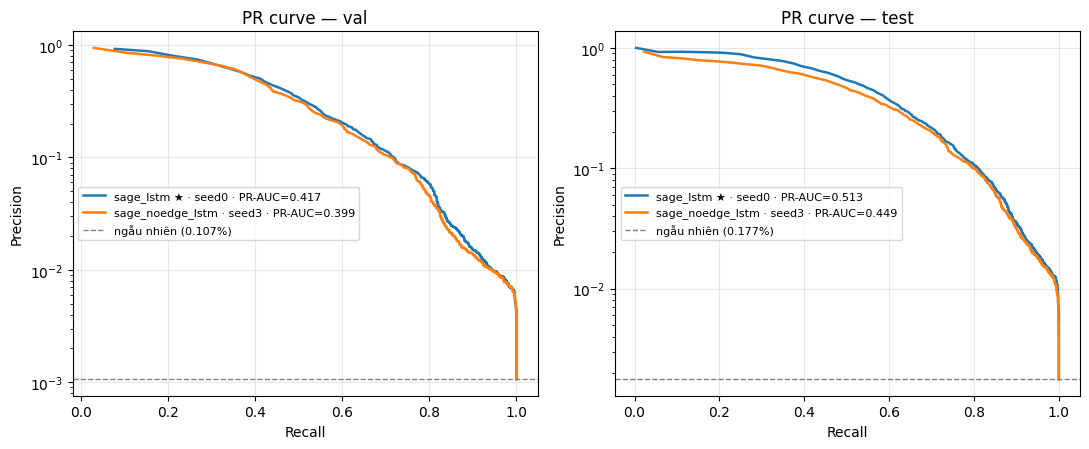

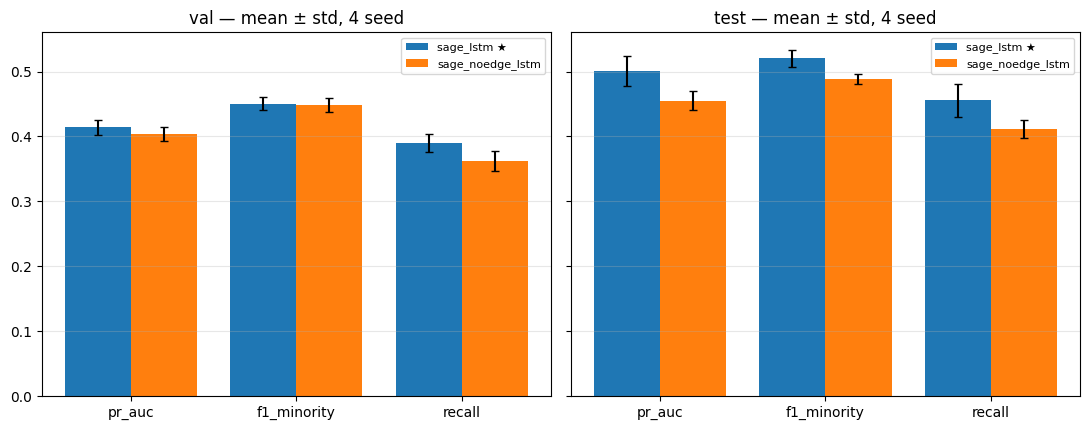

val   | TN=1,014,090 FP=430 FN=637 TP=445 | P=0.5086 R=0.4113 F1=0.4548
test  | TN=1,013,595 FP=489 FN=985 TP=813 | P=0.6244 R=0.4522 F1=0.5245


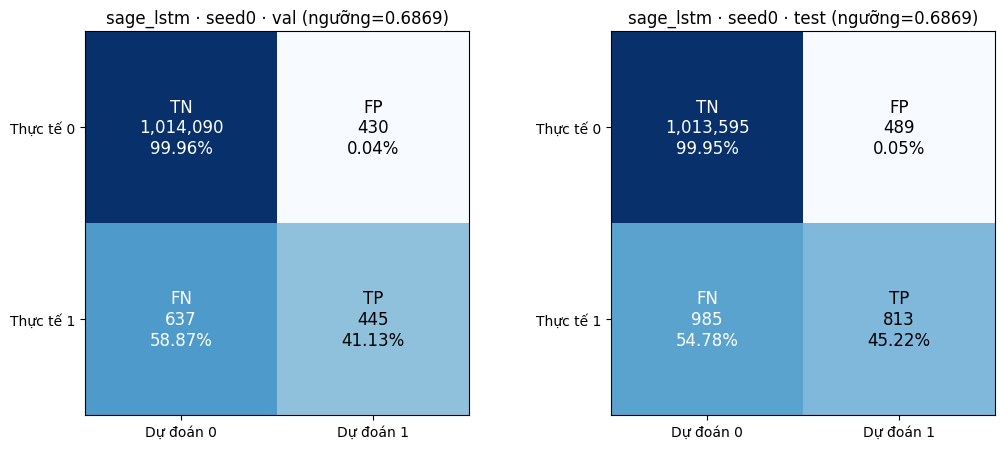

đã lưu: ['pr_curve.png', 'variant_bars.png', 'confusion_sage_lstm.png']


In [23]:
import os, sys, json
sys.path.insert(0, "/kaggle/working")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from paths import TXN_MATRIX, SCORES_DIR, RESULTS_CSV, WORK_DIR

FIG_DIR = os.path.join(WORK_DIR, "figures"); os.makedirs(FIG_DIR, exist_ok=True)
SPLITS, METRICS = ["val", "test"], ["pr_auc", "f1_minority", "recall"]

info = json.load(open(os.path.join(WORK_DIR, "winner.json")))
winner, tags = info["winner"], info["variants"]
res = pd.read_csv(RESULTS_CSV)
res = res[res.model.isin(tags)]

# seed đại diện = seed có pr_auc val gần TRUNG VỊ (không lấy seed cao nhất, tránh
# vẽ hình bằng một lần chạy may mắn)
v = res[res.split == "val"]
rep = {t: int(g.loc[(g.pr_auc - g.pr_auc.median()).abs().idxmin(), "seed"])
       for t, g in v.groupby("model")}
print("model thắng:", winner, "| seed đại diện:", rep)
print(res.groupby(["split", "model"])[METRICS].agg(["mean", "std"]).round(4))

y = {s: pd.read_parquet(TXN_MATRIX.format(s),
                        columns=["Is Laundering"])["Is Laundering"].to_numpy() for s in SPLITS}

# ---- Hình 1: PR curve ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, sp in zip(axes, SPLITS):
    for t in tags:
        s = np.load(f"{SCORES_DIR}/{t}_seed{rep[t]}_{sp}.npy")
        pr, rc, _ = precision_recall_curve(y[sp], s)
        pr, rc = pr[::100], rc[::100] 
        ap = res[(res.model == t) & (res.split == sp) & (res.seed == rep[t])].pr_auc.iloc[-1]
        ax.plot(rc, pr, lw=1.8,
                label=f"{t}{' ★' if t == winner else ''} · seed{rep[t]} · PR-AUC={ap:.3f}")
    base = y[sp].mean()
    ax.axhline(base, ls="--", c="gray", lw=1, label=f"ngẫu nhiên ({base*100:.3f}%)")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_yscale("log")
    ax.set_title(f"PR curve — {sp}"); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/pr_curve.png", dpi=150, bbox_inches="tight"); plt.show()

# ---- Hình 2: bar 3 chỉ số, error bar = std giữa seed ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
xs, w = np.arange(len(METRICS)), 0.8 / len(tags)
for ax, sp in zip(axes, SPLITS):
    g = res[res.split == sp].groupby("model")[METRICS]
    mu, sd = g.mean(), g.std()
    for i, t in enumerate(tags):
        ax.bar(xs + i * w - 0.4 + w / 2, mu.loc[t], w, yerr=sd.loc[t], capsize=3,
               label=t + (" ★" if t == winner else ""))
    ax.set_xticks(xs); ax.set_xticklabels(METRICS)
    ax.set_title(f"{sp} — mean ± std, {len(info['seeds'])} seed")
    ax.grid(axis="y", alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/variant_bars.png", dpi=150, bbox_inches="tight"); plt.show()

# ---- Hình 3: confusion matrix của model thắng ----
SEED = rep[winner]
thr = res[(res.model == winner) & (res.seed == SEED) & (res.split == "val")].threshold.iloc[-1]
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.6))
for ax, sp in zip(axes, SPLITS):
    p = (np.load(f"{SCORES_DIR}/{winner}_seed{SEED}_{sp}.npy") >= thr).astype(int)
    cm = np.array([[int(((y[sp] == a) & (p == b)).sum()) for b in (0, 1)] for a in (0, 1)])
    row = cm / cm.sum(axis=1, keepdims=True)          # chuẩn hoá theo HÀNG = lớp thực tế
    ax.imshow(row, cmap="Blues", vmin=0, vmax=1)
    name = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{name[i][j]}\n{cm[i, j]:,}\n{row[i, j]*100:.2f}%", ha="center",
                    va="center", fontsize=12, color="white" if row[i, j] > .5 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Dự đoán 0", "Dự đoán 1"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Thực tế 0", "Thực tế 1"])
    ax.set_title(f"{winner} · seed{SEED} · {sp} (ngưỡng={thr:.4f})")
    tn, fp, fn, tp = cm.ravel()
    pr_, rc_ = tp / max(tp + fp, 1), tp / max(tp + fn, 1)
    print(f"{sp:5s} | TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,} | P={pr_:.4f} R={rc_:.4f} "
          f"F1={2*pr_*rc_/max(pr_+rc_, 1e-12):.4f}")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/confusion_{winner}.png", dpi=150, bbox_inches="tight"); plt.show()

print("đã lưu:", os.listdir(FIG_DIR))

In [24]:
# Cell cuối — đóng gói embedding rồi tải về
import os, sys, glob, zipfile
sys.path.insert(0, "/kaggle/working")
from paths import SCORES_DIR, WORK_DIR
from IPython.display import FileLink, display

emb = sorted(glob.glob(f"{SCORES_DIR}/emb_*.npy"))
assert emb, "không có file emb_*.npy,train_gnn.py chưa chạy xong"

# ZIP_STORED: .npy float32 nén gần như vô ích, gói-không-nén nhanh hơn nhiều lần
out = os.path.join(WORK_DIR, "emb-lstm.zip")
with zipfile.ZipFile(out, "w", zipfile.ZIP_STORED) as z:
    for p in emb:
        z.write(p, os.path.basename(p))
print(f"emb-lstm.zip: {len(emb)} file | {os.path.getsize(out)/1e6:,.0f} MB")
display(FileLink("emb-lstm.zip"))

print(f"\n/kaggle/working hiện: "
      f"{sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk('/kaggle/working') for f in fs)/1e9:.2f} GB")

emb-lstm.zip: 24 file | 1,582 MB


/kaggle/working/emb-lstm.zip


/kaggle/working hiện: 8.35 GB


In [25]:
# Cell cuối — gói toàn bộ /kaggle/working/scores
import os, sys, glob, zipfile, datetime
sys.path.insert(0, "/kaggle/working")
from paths import SCORES_DIR, WORK_DIR
from IPython.display import FileLink, display

files = sorted(glob.glob(f"{SCORES_DIR}/*.npy"))
for p in files:                                  # mtime để phân biệt lần chạy cũ/mới
    print(f"{os.path.getsize(p)/1e6:>7,.1f} MB  "
          f"{datetime.datetime.fromtimestamp(os.path.getmtime(p)):%m-%d %H:%M}  "
          f"{os.path.basename(p)}")

out = os.path.join(WORK_DIR, "scores.zip")
with zipfile.ZipFile(out, "w", zipfile.ZIP_STORED) as z:   # không nén: float32 nén vô ích
    for p in files:
        z.write(p, os.path.basename(p))

print(f"\nscores.zip: {len(files)} file | {os.path.getsize(out)/1e6:,.0f} MB")
display(FileLink("scores.zip"))

   65.9 MB  08-15 08:09  emb_sage_lstm_seed0_test.npy
   65.9 MB  08-15 08:09  emb_sage_lstm_seed0_train.npy
   65.9 MB  08-15 08:09  emb_sage_lstm_seed0_val.npy
   65.9 MB  08-15 08:15  emb_sage_lstm_seed1_test.npy
   65.9 MB  08-15 08:15  emb_sage_lstm_seed1_train.npy
   65.9 MB  08-15 08:15  emb_sage_lstm_seed1_val.npy
   65.9 MB  08-15 08:20  emb_sage_lstm_seed2_test.npy
   65.9 MB  08-15 08:20  emb_sage_lstm_seed2_train.npy
   65.9 MB  08-15 08:20  emb_sage_lstm_seed2_val.npy
   65.9 MB  08-15 08:25  emb_sage_lstm_seed3_test.npy
   65.9 MB  08-15 08:25  emb_sage_lstm_seed3_train.npy
   65.9 MB  08-15 08:25  emb_sage_lstm_seed3_val.npy
   65.9 MB  08-15 08:29  emb_sage_noedge_lstm_seed0_test.npy
   65.9 MB  08-15 08:29  emb_sage_noedge_lstm_seed0_train.npy
   65.9 MB  08-15 08:29  emb_sage_noedge_lstm_seed0_val.npy
   65.9 MB  08-15 08:34  emb_sage_noedge_lstm_seed1_test.npy
   65.9 MB  08-15 08:34  emb_sage_noedge_lstm_seed1_train.npy
   65.9 MB  08-15 08:34  emb_sage_noedge_lstm_

/kaggle/working/scores.zip